# EVO 5

## plot dual axis depth profile

In [2]:
import h5py
from plot_style import decode_stamps_to_datetimeindex, plot_dual_axis_depth_profile
from matplotlib.ticker import MultipleLocator


# --- 数据源 1（左轴） ---
f1 = h5py.File('C:/Users/fengxiang.mao/Desktop/Devon data/HFTS-1_Devon/20220707/Evo 3 (refrac)/Neubrex_DSS_strain/Zgabay A14H - refrac - strain change.h5','r')

dstrain1 = f1["data"]      # (Nt1, Nz1)
depth1   = f1["depth"]     # (Nz1,)
stamps1  = decode_stamps_to_datetimeindex(f1["stamps"], fmt='%m/%d/%Y %H:%M:%S.%f')  # 如果是其它格式，改这里
times_left = ["2022-01-29 05:23:46"]
window_left = (12000.0, 18000.0)

# --- 数据源 2（右轴） ---
f2 = h5py.File('C:/Users/fengxiang.mao/Desktop/Devon data/HFTS-1_Devon/20220707/Evo 5 (POP)/Zgabay A14H - pop - strain change.h5','r')
dstrain2 = f2["data"]      # (Nt2, Nz2)
depth2   = f2["depth"]     # (Nz2,)
stamps2  = decode_stamps_to_datetimeindex(f2["stamps"], fmt='%m/%d/%Y %H:%M:%S.%f')
times_right = ["2022-03-16 20:50:03"] 
window_right = (12000.0, 16400.0)

# --- 画图：x 轴强制 12000–18000 ft，双 y 轴 ---
fig, ax_left, ax_right = plot_dual_axis_depth_profile(
    dstrain_left=dstrain1, depth_left=depth1, times_left=times_left,
    dstrain_right=dstrain2, depth_right=depth2, times_right=times_right,
    depth_window_left=window_left,
    depth_window_right=window_right,
    stamps_index_left=stamps1,
    stamps_index_right=stamps2,

    depth_unit="ft",
    strain_unit_left="(microstrain)",    # 自己改单位显示
    strain_unit_right="(microstrain)",   # 自己改单位显示

    # 如果要取反显示，可以这样开：
    # strain_scale_left=-1.0,
    # strain_scale_right=-1.0,

    invert_left_y=False,                 # ← 左轴是否反转
    invert_right_y=False,                # ← 右轴是否反转
    xlim=(12000.0, 18000.0),             # ← 固定 x 范围
    figsize=(12, 6),
    labels=("Refrac (Left)", "Pop (Right)"),  # 图例前缀
)

# 正常方向（下小上大）
ax_left.set_ylim(-60, 30)
ax_left.yaxis.set_major_locator(MultipleLocator(20))   # 左轴主刻度步长 100

ax_right.set_ylim(-20, 10)
# ax_right.set_yticks([-50, -30, -10, 10])      # 右轴指定刻度
ax_right.yaxis.set_major_locator(MultipleLocator(10))   # 左轴主刻度步长 100
# ax_right.invert_yaxis()

FileNotFoundError: [Errno 2] Unable to open file (unable to open file: name = 'C:/Users/fengxiang.mao/Desktop/Devon data/HFTS-1_Devon/20220707/Evo 3 (refrac)/Neubrex_DSS_strain/Zgabay A14H - refrac - strain change.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

## MD calibration

In [3]:

import h5py
from matplotlib.ticker import MultipleLocator
from plot_style import decode_stamps_to_datetimeindex, plot_dual_axis_depth_profile
from slippage_clbrt_shift import shift_depth_piecewise


# ----------------- 你的原始代码 -----------------
# 左轴（refrac）
f1 = h5py.File('C:/Users/fengxiang.mao/Desktop/Devon data/HFTS-1_Devon/20220707/Evo 3 (refrac)/Neubrex_DSS_strain/Zgabay A14H - refrac - strain change.h5','r')
dstrain1 = f1["data"]
depth1   = f1["depth"]
stamps1  = decode_stamps_to_datetimeindex(f1["stamps"], fmt='%m/%d/%Y %H:%M:%S.%f')
times_left  = ["2022-01-29 05:23:46"]
window_left = (12000.0, 18000.0)

# 右轴（POP）
f2 = h5py.File('C:/Users/fengxiang.mao/Desktop/Devon data/HFTS-1_Devon/20220707/Evo 5 (POP)/Zgabay A14H - pop - strain change.h5','r')
dstrain2 = f2["data"]
depth2   = f2["depth"]
stamps2  = decode_stamps_to_datetimeindex(f2["stamps"], fmt='%m/%d/%Y %H:%M:%S.%f')
times_right  = ["2022-03-16 20:50:03"]

# === 关键：对 POP 的深度做“分段线性右移” ===
depth2_shifted = shift_depth_piecewise(depth2, z0=12000.0, z1=16000.0, s0=145.0, s1=160.0)

# 右轴选取窗口：现在是“基于平移后的深度”来筛列（保持你原来的 12000~16400）
window_right = (12000.0, 16400.0)

# --- 画图：x 轴强制 12000–18000 ft，双 y 轴 ---
fig, ax_left, ax_right = plot_dual_axis_depth_profile(
    dstrain_left=dstrain1, depth_left=depth1,          times_left=times_left,
    dstrain_right=dstrain2, depth_right=depth2_shifted, times_right=times_right,  # ← 用平移后的 depth
    depth_window_left=window_left,
    depth_window_right=window_right,
    stamps_index_left=stamps1,
    stamps_index_right=stamps2,

    depth_unit="ft",
    strain_unit_left="(microstrain)",
    strain_unit_right="(microstrain)",

    invert_left_y=False,
    invert_right_y=False,
    xlim=(12000.0, 18000.0),
    figsize=(12, 6),
    labels=("Refrac (Left)", "POP shifted (Right)"),
)

# 轴范围/刻度
ax_left.set_ylim(-60, 30)
ax_left.yaxis.set_major_locator(MultipleLocator(20))
ax_right.set_ylim(-15, 10)
ax_right.yaxis.set_major_locator(MultipleLocator(5))


FileNotFoundError: [Errno 2] Unable to open file (unable to open file: name = 'C:/Users/fengxiang.mao/Desktop/Devon data/HFTS-1_Devon/20220707/Evo 3 (refrac)/Neubrex_DSS_strain/Zgabay A14H - refrac - strain change.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [1]:
import numpy as np
from slippage_clbrt_shift import shift_depth_piecewise, invert_shift_depth_piecewise

gauges = np.array([13004, 15321, 13753.1])
gauge_to_fiber = invert_shift_depth_piecewise(gauges, z0=12000.0, z1=16000.0, s0=145.0, s1=160.0)
print("测点深度 gauges: ", gauges)
print("对应纤维深度 gauge_to_fiber: ", gauge_to_fiber)


测点深度 gauges:  [13004.  15321.  13753.1]
对应纤维深度 gauge_to_fiber:  [12855.79078456 15164.13449564 13602.09215442]


In [4]:
fibers = np.array([12660.6, 12678.7, 12842.0, 13602.7, 13707.9, 13868.5, 13872.4, 13877.7, 14225.3, 14235.5, 
                   14252.3, 14260.2, 14496.3, 14824.1, 14839.0, 15092.2, 15105.7, 15412.0, 15648.1, 15712.8, 16458.3])

fiber_to_gauge = shift_depth_piecewise(fibers, z0=12000.0, z1=16000.0, s0=145.0, s1=160.0)
print("纤维深度 fibers: ", fibers)
print("对应测点深度 fiber_to_gauge: ", fiber_to_gauge)


纤维深度 fibers:  [12660.6 12678.7 12842.  13602.7 13707.9 13868.5 13872.4 13877.7 14225.3
 14235.5 14252.3 14260.2 14496.3 14824.1 14839.  15092.2 15105.7 15412.
 15648.1 15712.8 16458.3]
对应测点深度 fiber_to_gauge:  [12808.07725  12826.245125 12990.1575   13753.710125 13859.304625
 14020.506875 14024.4215   14029.741375 14378.644875 14388.883125
 14405.746125 14413.67575  14650.661125 14979.690375 14994.64625
 15248.79575  15262.346375 15569.795    15806.780375 15871.723
 16618.3     ]


In [3]:
# EVO 7  to EVO 5 (POP)
import numpy as np
from slippage_clbrt_shift import shift_depth_piecewise, invert_shift_depth_piecewise

Evo7 = np.array([13100.3, 13119.5])
EVO5 = shift_depth_piecewise(Evo7, z0=12000.0, z1=16000.0, s0=-40.0, s1=-45.0)
print("Evo7: ", Evo7)
print("EVO5: ", EVO5)

Evo7:  [13100.3 13119.5]
EVO5:  [13058.924625 13078.100625]


# EVO 5 & 7 

In [4]:
import h5py
import numpy as np
import pandas as pd
from plot_style import decode_stamps_to_datetimeindex, plot_dual_axis_depth_profile
from slippage_clbrt_shift import shift_depth_piecewise
from matplotlib.ticker import MultipleLocator

def find_nearest_time_index(idx: pd.DatetimeIndex, target: pd.Timestamp) -> int:
    deltas = idx - target
    return int(np.abs(deltas).argmin())

def build_interval_profile_from_file(
    h5_path: str,
    data_key: str,
    t_start: str,   # e.g. "2022-03-16 20:10:00"
    t_end: str,     # e.g. "2022-03-16 20:50:03"
    stamp_fmt: str = '%m/%d/%Y %H:%M:%S.%f',
    sign: float = 1.0
):
    """
    返回：
      interval_profile_full: shape (ndepth,)  = sign * (profile_end - profile_start)
      depth:                shape (ndepth,)
      fake_dstrain_2d:       shape (1, ndepth)  (为了兼容原 plot 函数)
      fake_stamps_idx:       DatetimeIndex([matched_end_time])
      fake_time_str:         用于 times_right 的字符串
      debug:                 (i_start, matched_start, i_end, matched_end)
    """
    f = h5py.File(h5_path, "r")
    dstrain = f[data_key][...]          # (ntime, ndepth)
    depth   = np.asarray(f["depth"][...])
    stamps  = f["stamps"]
    stamps_idx = decode_stamps_to_datetimeindex(stamps, fmt=stamp_fmt)

    t_start_ts = pd.to_datetime(t_start)
    t_end_ts   = pd.to_datetime(t_end)

    i0 = find_nearest_time_index(stamps_idx, t_start_ts)
    i1 = find_nearest_time_index(stamps_idx, t_end_ts)

    prof0 = dstrain[i0, :]
    prof1 = dstrain[i1, :]
    interval_profile_full = sign * (prof1 - prof0)

    # ★关键：包装成“只有 1 行”的 2D，伪装成一个“时间点”
    fake_dstrain_2d = interval_profile_full[None, :]  # (1, ndepth)
    fake_stamps_idx = pd.DatetimeIndex([stamps_idx[i1]])
    fake_time_str   = str(fake_stamps_idx[0])

    debug = (i0, stamps_idx[i0], i1, stamps_idx[i1])
    return interval_profile_full, depth, fake_dstrain_2d, fake_stamps_idx, fake_time_str, debug


LEFT interval matched: (514, Timestamp('2022-03-15 09:00:21.241823'), 1024, Timestamp('2022-03-15 21:00:08.100242'))
POP interval matched: (566, Timestamp('2022-06-02 08:00:07.017492'), 1218, Timestamp('2022-06-03 11:59:53.654046'))


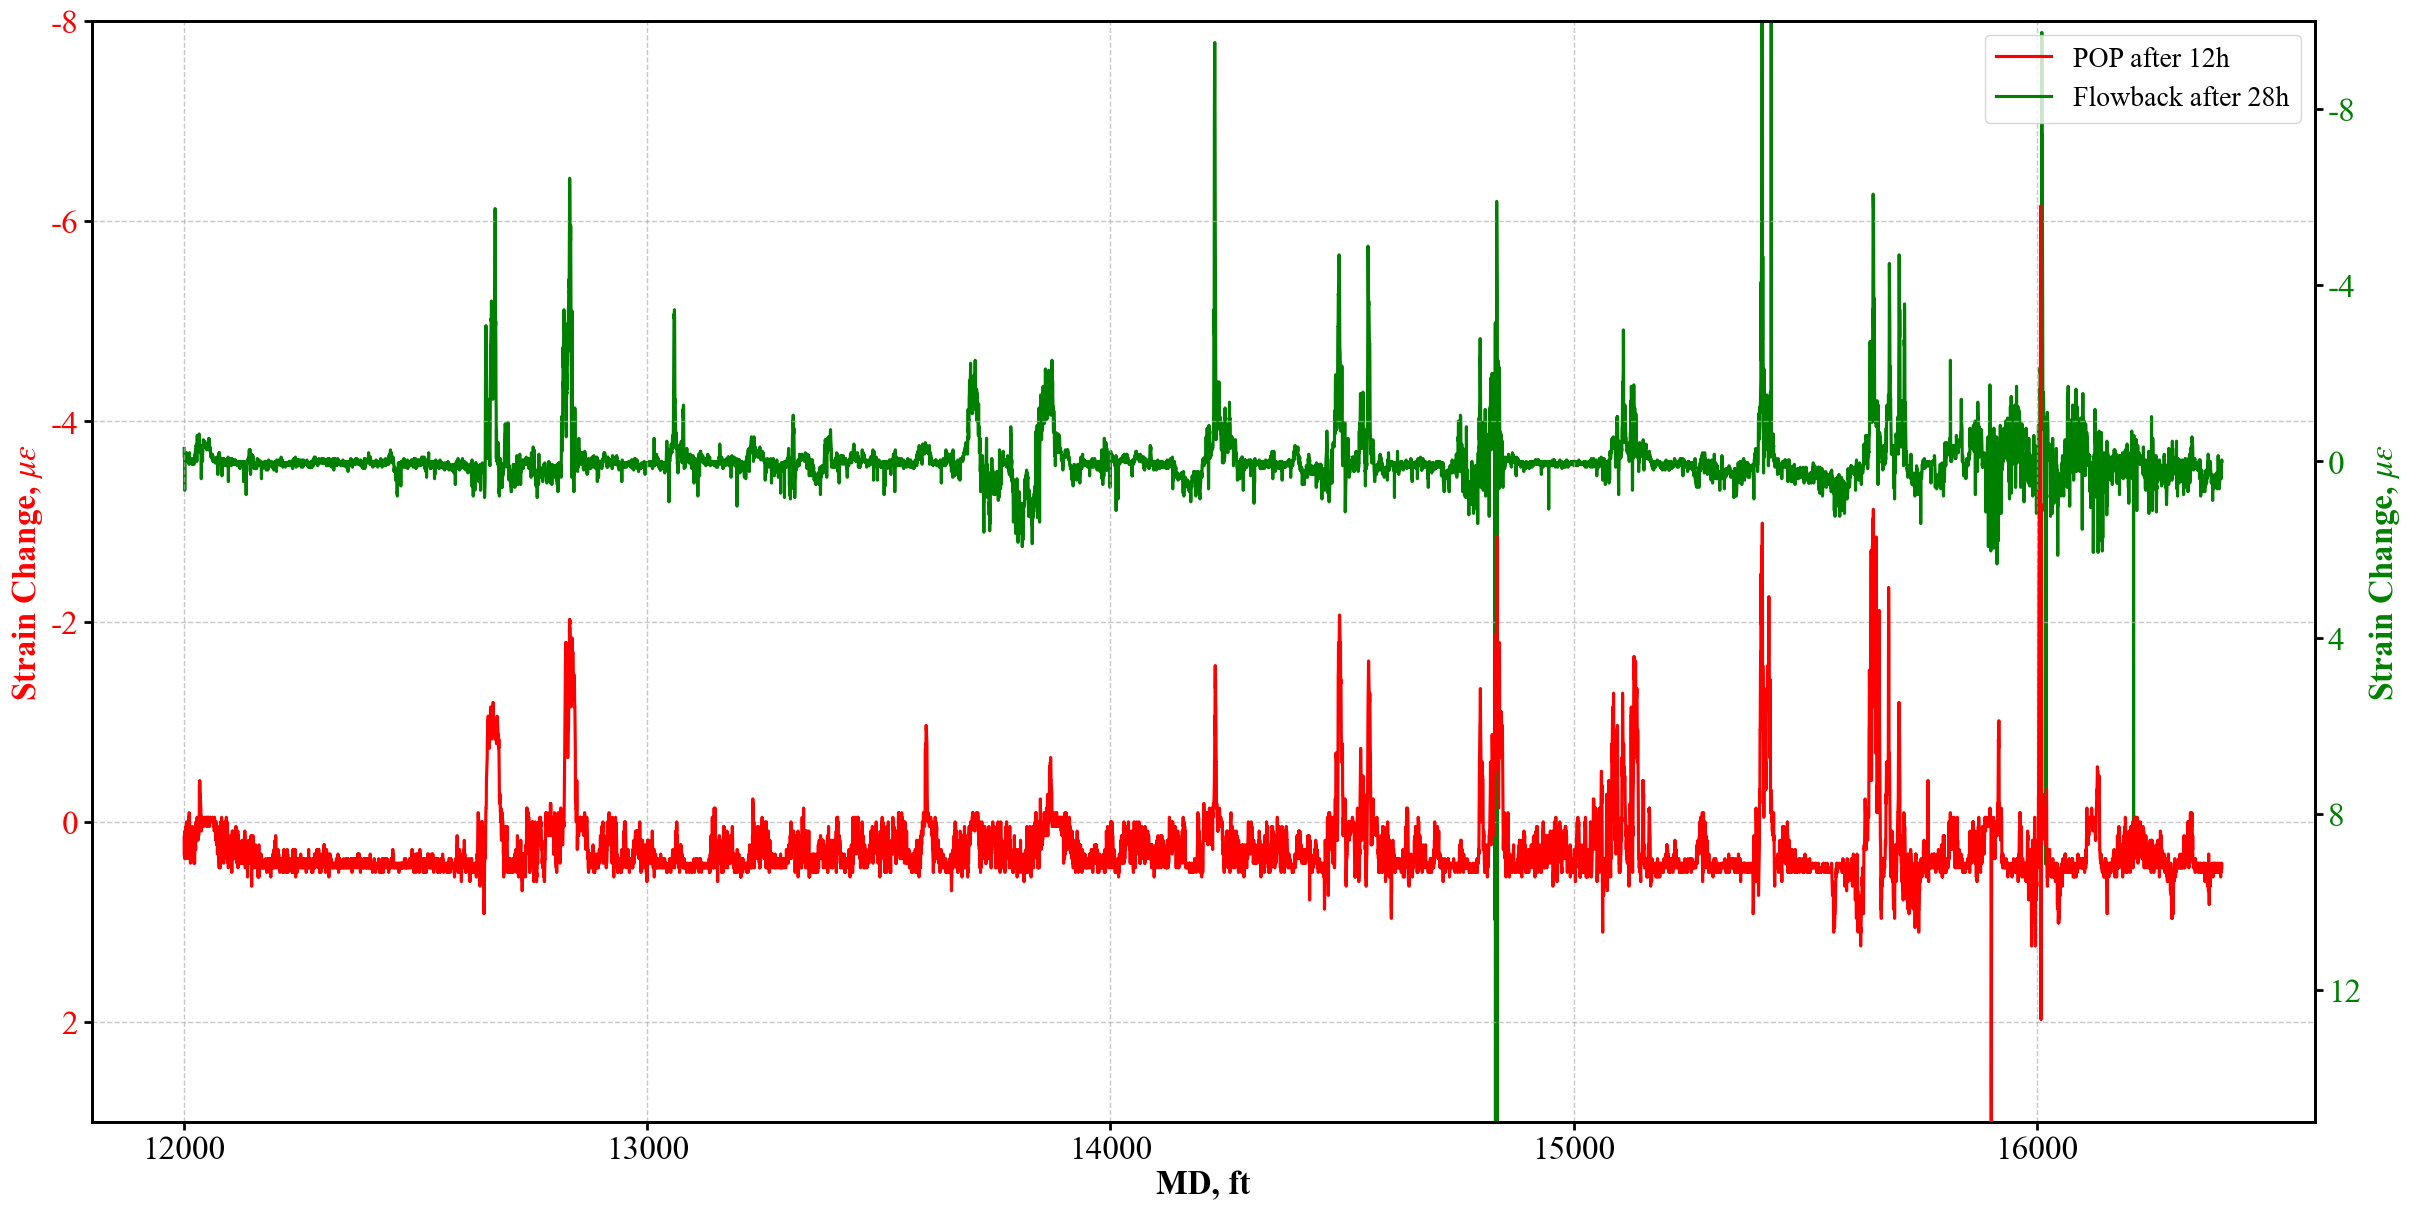

In [5]:
%reload_ext autoreload
%autoreload 2

# =========================================================
# 左图（POP）也改成 interval profile：t_end - t_start
# =========================================================
left_path = r'C:/Users/fengxiang.mao/Desktop/Devon data/HFTS-1_Devon/20220707/Evo 5 (POP)/Zgabay A14H - pop - strain change.h5'

t_start_left = "2022-03-15 09:00:00"
t_end_left   = "2022-03-15 21:00:00"

interval_prof_left, depth1, dstrain1_fake, stamps1_fake, time_left_fake, dbg_left = build_interval_profile_from_file(
    h5_path=left_path,
    data_key="data",
    t_start=t_start_left,
    t_end=t_end_left,
    stamp_fmt='%m/%d/%Y %H:%M:%S.%f',
    sign=1.0
)

print("LEFT interval matched:", dbg_left)

times_left  = [time_left_fake]
window_left = (12000.0, 16400.0)


# -------------------------
# 右轴（POP）改成 interval profile：t_end - t_start
# -------------------------
flowback_path = 'C:/Users/fengxiang.mao/Desktop/Devon data/HFTS-1_Devon/Evo_5_6_7_Sep_2025/Evo 7 (flowback)/corrected_within_1h_(with_data_wash).h5'


# 你自己填 interval 的两个时间点（示例）
t_start = "2022-06-02 08:00:00"
t_end   = "2022-06-03 12:00:00"

# sign=1 或 -1 看你想让 interval 的方向和你 output1 一致
interval_prof, depth2, dstrain2_fake, stamps2_fake, time_right_fake, dbg = build_interval_profile_from_file(
    h5_path=flowback_path,
    data_key="strain_corrected",
    t_start=t_start,
    t_end=t_end,
    stamp_fmt='%m/%d/%Y %H:%M:%S.%f',
    sign=1.0
)

print("POP interval matched:", dbg)
times_right = [time_right_fake]  # 注意：这是“伪造的唯一时间点”
# stamps_index_right 用 stamps2_fake
# dstrain_right 用 dstrain2_fake


# === 深度做分段 shift（保持你原来的 calibration 逻辑）===
depth2_shifted = shift_depth_piecewise(depth2, z0=12000.0, z1=16000.0, s0=-40, s1=-45)

window_right = (12000.0, 16400.0)

# -------------------------
# 画图：基本不改 plot_dual_axis_depth_profile 的接口
# -------------------------

fig, ax_left, ax_right = plot_dual_axis_depth_profile(
    dstrain_left=dstrain1_fake,
    depth_left=depth1,
    times_left=times_left,

    dstrain_right=dstrain2_fake,
    depth_right=depth2_shifted,
    times_right=times_right,

    depth_window_left=window_left,
    depth_window_right=window_right,

    stamps_index_left=stamps1_fake,
    stamps_index_right=stamps2_fake,

    depth_unit="ft",
    strain_unit_left=r"$\mu\varepsilon$",
    strain_unit_right=r"$\mu\varepsilon$",

    invert_left_y=False,
    invert_right_y=False,
    xlim=(12000.0, 16400.0),
    figsize=(24, 12),

    # 这里建议标签也改成 interval 含义
    labels=("POP after 12h", "Flowback after 28h"),
)


ax_left.set_xlim(12000-200, 16400+200)

ax_left.set_xticks(np.arange(12000, 16401, 1000))

ax_left.set_ylim(3, -8)
ax_left.yaxis.set_major_locator(MultipleLocator(2))

ax_right.set_ylim(15, -10)
ax_right.yaxis.set_major_locator(MultipleLocator(4))
# ax_right.lines[0].set_linestyle("-")



# 假设左轴第一条线是 refrac，右轴第一条线是 POP interval
ax_left.lines[0].set_zorder(10)   # 画到上面
ax_right.lines[0].set_zorder(5)   # 放下面（可选）

# 如果你发现“还是被盖住”，加上这句让上面的线不被轴背景挡住
ax_left.set_zorder(2)
ax_right.set_zorder(1)
ax_left.patch.set_alpha(0)        # 左轴背景透明，避免遮挡右轴线

ax_left.grid(True, linestyle='--',alpha=0.7)



In [6]:
print("left lines:", len(ax_left.lines))
print("right lines:", len(ax_right.lines))

left lines: 1
right lines: 1


LEFT interval matched: (514, Timestamp('2022-03-15 09:00:21.241823'), 1024, Timestamp('2022-03-15 21:00:08.100242'))
POP interval matched: (566, Timestamp('2022-06-02 08:00:07.017492'), 846, Timestamp('2022-06-02 20:01:17.307828'))


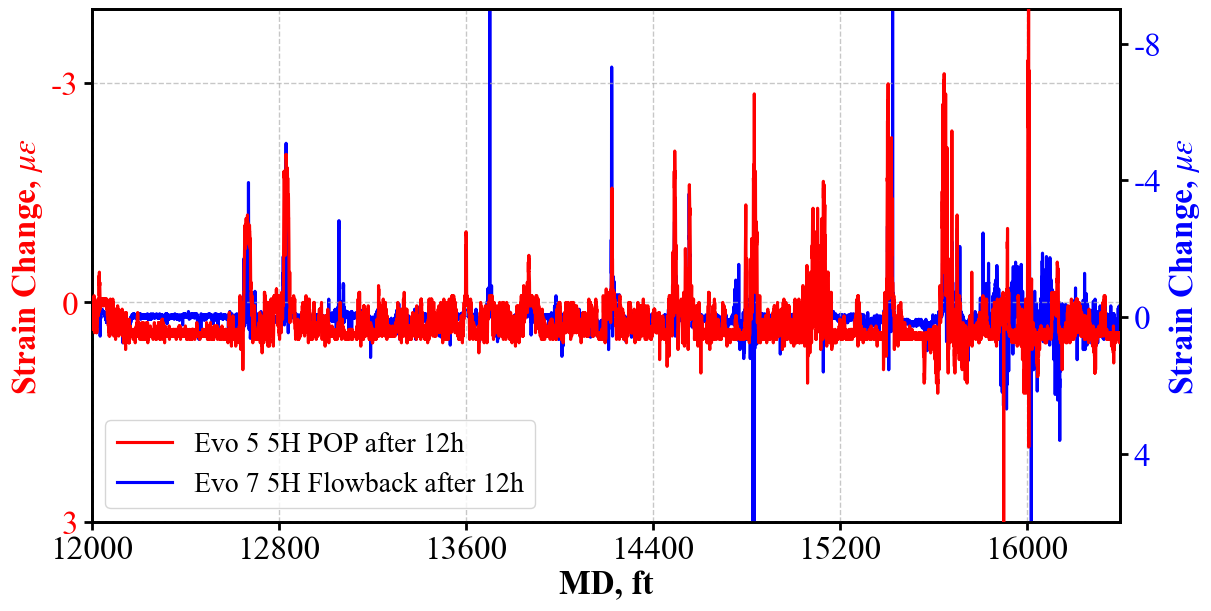

In [11]:
%reload_ext autoreload
%autoreload 2

# =========================================================
# 左图（POP）也改成 interval profile：t_end - t_start
# =========================================================
left_path = r'C:/Users/fengxiang.mao/Desktop/Devon data/HFTS-1_Devon/20220707/Evo 5 (POP)/Zgabay A14H - pop - strain change.h5'

t_start_left = "2022-03-15 09:00:00"
t_end_left   = "2022-03-15 21:00:00"

interval_prof_left, depth1, dstrain1_fake, stamps1_fake, time_left_fake, dbg_left = build_interval_profile_from_file(
    h5_path=left_path,
    data_key="data",
    t_start=t_start_left,
    t_end=t_end_left,
    stamp_fmt='%m/%d/%Y %H:%M:%S.%f',
    sign=1.0
)

print("LEFT interval matched:", dbg_left)

times_left  = [time_left_fake]
window_left = (12000.0, 16400.0)


# -------------------------
# 右轴（POP）改成 interval profile：t_end - t_start
# -------------------------
pop_path = 'C:/Users/fengxiang.mao/Desktop/Devon data/HFTS-1_Devon/Evo_5_6_7_Sep_2025/Evo 7 (flowback)/corrected_within_1h_(with_data_wash).h5'


# 你自己填 interval 的两个时间点（示例）
t_start = "2022-06-02 08:00:00"
t_end   = "2022-06-02 20:00:00"

# sign=1 或 -1 看你想让 interval 的方向和你 output1 一致
interval_prof, depth2, dstrain2_fake, stamps2_fake, time_right_fake, dbg = build_interval_profile_from_file(
    h5_path=pop_path,
    data_key="strain_corrected",
    t_start=t_start,
    t_end=t_end,
    stamp_fmt='%m/%d/%Y %H:%M:%S.%f',
    sign=1.0
)

print("POP interval matched:", dbg)
times_right = [time_right_fake]  # 注意：这是“伪造的唯一时间点”
# stamps_index_right 用 stamps2_fake
# dstrain_right 用 dstrain2_fake


# === 深度做分段 shift（保持你原来的 calibration 逻辑）===
depth2_shifted = shift_depth_piecewise(depth2, z0=12000.0, z1=16000.0, s0=-40, s1=-45)
# depth2_shifted = shift_depth_piecewise(depth2, z0=12000.0, z1=16000.0, s0=0, s1=0)

window_right = (12000.0, 16400.0)

# -------------------------
# 画图：基本不改 plot_dual_axis_depth_profile 的接口
# -------------------------

fig, ax_left, ax_right = plot_dual_axis_depth_profile(
    dstrain_left=dstrain1_fake,
    depth_left=depth1,
    times_left=times_left,

    dstrain_right=dstrain2_fake,
    depth_right=depth2_shifted,
    times_right=times_right,

    depth_window_left=window_left,
    depth_window_right=window_right,

    stamps_index_left=stamps1_fake,
    stamps_index_right=stamps2_fake,

    depth_unit="ft",
    strain_unit_left=r"$\mu\varepsilon$",
    strain_unit_right=r"$\mu\varepsilon$",

    invert_left_y=False,
    invert_right_y=False,
    xlim=(12000.0, 16400.0),
    figsize=(12, 6),

    # 这里建议标签也改成 interval 含义
    labels=("Evo 5 5H POP after 12h", f"Evo 7 5H Flowback after 12h"),
    color_cycle=('r','b', 'g', 'm', 'c', 'y'),
)


ax_left.set_ylim(3, -4)
ax_left.yaxis.set_major_locator(MultipleLocator(3))

ax_right.set_ylim(6, -9)
ax_right.yaxis.set_major_locator(MultipleLocator(4))
# ax_right.lines[0].set_linestyle("-")



# 假设左轴第一条线是 refrac，右轴第一条线是 POP interval
ax_left.lines[0].set_zorder(10)   # 画到上面
ax_right.lines[0].set_zorder(5)   # 放下面（可选）

# 如果你发现“还是被盖住”，加上这句让上面的线不被轴背景挡住
ax_left.set_zorder(2)
ax_right.set_zorder(1)
ax_left.patch.set_alpha(0)        # 左轴背景透明，避免遮挡右轴线

ax_left.grid(True, linestyle='--',alpha=0.7)

leg = ax_left.legend_
if leg is not None:
    leg.set_zorder(1000)
    leg.get_frame().set_alpha(0.8)

# EVO 5 & 6

In [22]:
import h5py
import numpy as np
import pandas as pd
from plot_style import decode_stamps_to_datetimeindex, plot_dual_axis_depth_profile
from slippage_clbrt_shift import shift_depth_piecewise
from matplotlib.ticker import MultipleLocator

def find_nearest_time_index(idx: pd.DatetimeIndex, target: pd.Timestamp) -> int:
    deltas = idx - target
    return int(np.abs(deltas).argmin())

def build_interval_profile_from_file(
    h5_path: str,
    data_key: str,
    t_start: str,   # e.g. "2022-03-16 20:10:00"
    t_end: str,     # e.g. "2022-03-16 20:50:03"
    stamp_fmt: str = '%m/%d/%Y %H:%M:%S.%f',
    sign: float = 1.0
):
    """
    返回：
      interval_profile_full: shape (ndepth,)  = sign * (profile_end - profile_start)
      depth:                shape (ndepth,)
      fake_dstrain_2d:       shape (1, ndepth)  (为了兼容原 plot 函数)
      fake_stamps_idx:       DatetimeIndex([matched_end_time])
      fake_time_str:         用于 times_right 的字符串
      debug:                 (i_start, matched_start, i_end, matched_end)
    """
    f = h5py.File(h5_path, "r")
    dstrain = f[data_key][...]          # (ntime, ndepth)
    depth   = np.asarray(f["depth"][...])
    stamps  = f["stamps"]
    stamps_idx = decode_stamps_to_datetimeindex(stamps, fmt=stamp_fmt)

    t_start_ts = pd.to_datetime(t_start)
    t_end_ts   = pd.to_datetime(t_end)

    i0 = find_nearest_time_index(stamps_idx, t_start_ts)
    i1 = find_nearest_time_index(stamps_idx, t_end_ts)

    prof0 = dstrain[i0, :]
    prof1 = dstrain[i1, :]
    interval_profile_full = sign * (prof1 - prof0)

    # ★关键：包装成“只有 1 行”的 2D，伪装成一个“时间点”
    fake_dstrain_2d = interval_profile_full[None, :]  # (1, ndepth)
    fake_stamps_idx = pd.DatetimeIndex([stamps_idx[i1]])
    fake_time_str   = str(fake_stamps_idx[0])

    debug = (i0, stamps_idx[i0], i1, stamps_idx[i1])
    return interval_profile_full, depth, fake_dstrain_2d, fake_stamps_idx, fake_time_str, debug


LEFT interval matched: (514, Timestamp('2022-03-15 09:00:21.241823'), 1024, Timestamp('2022-03-15 21:00:08.100242'))
POP interval matched: (458, Timestamp('2022-04-03 00:59:32.245172'), 903, Timestamp('2022-04-04 00:59:01.205751'))


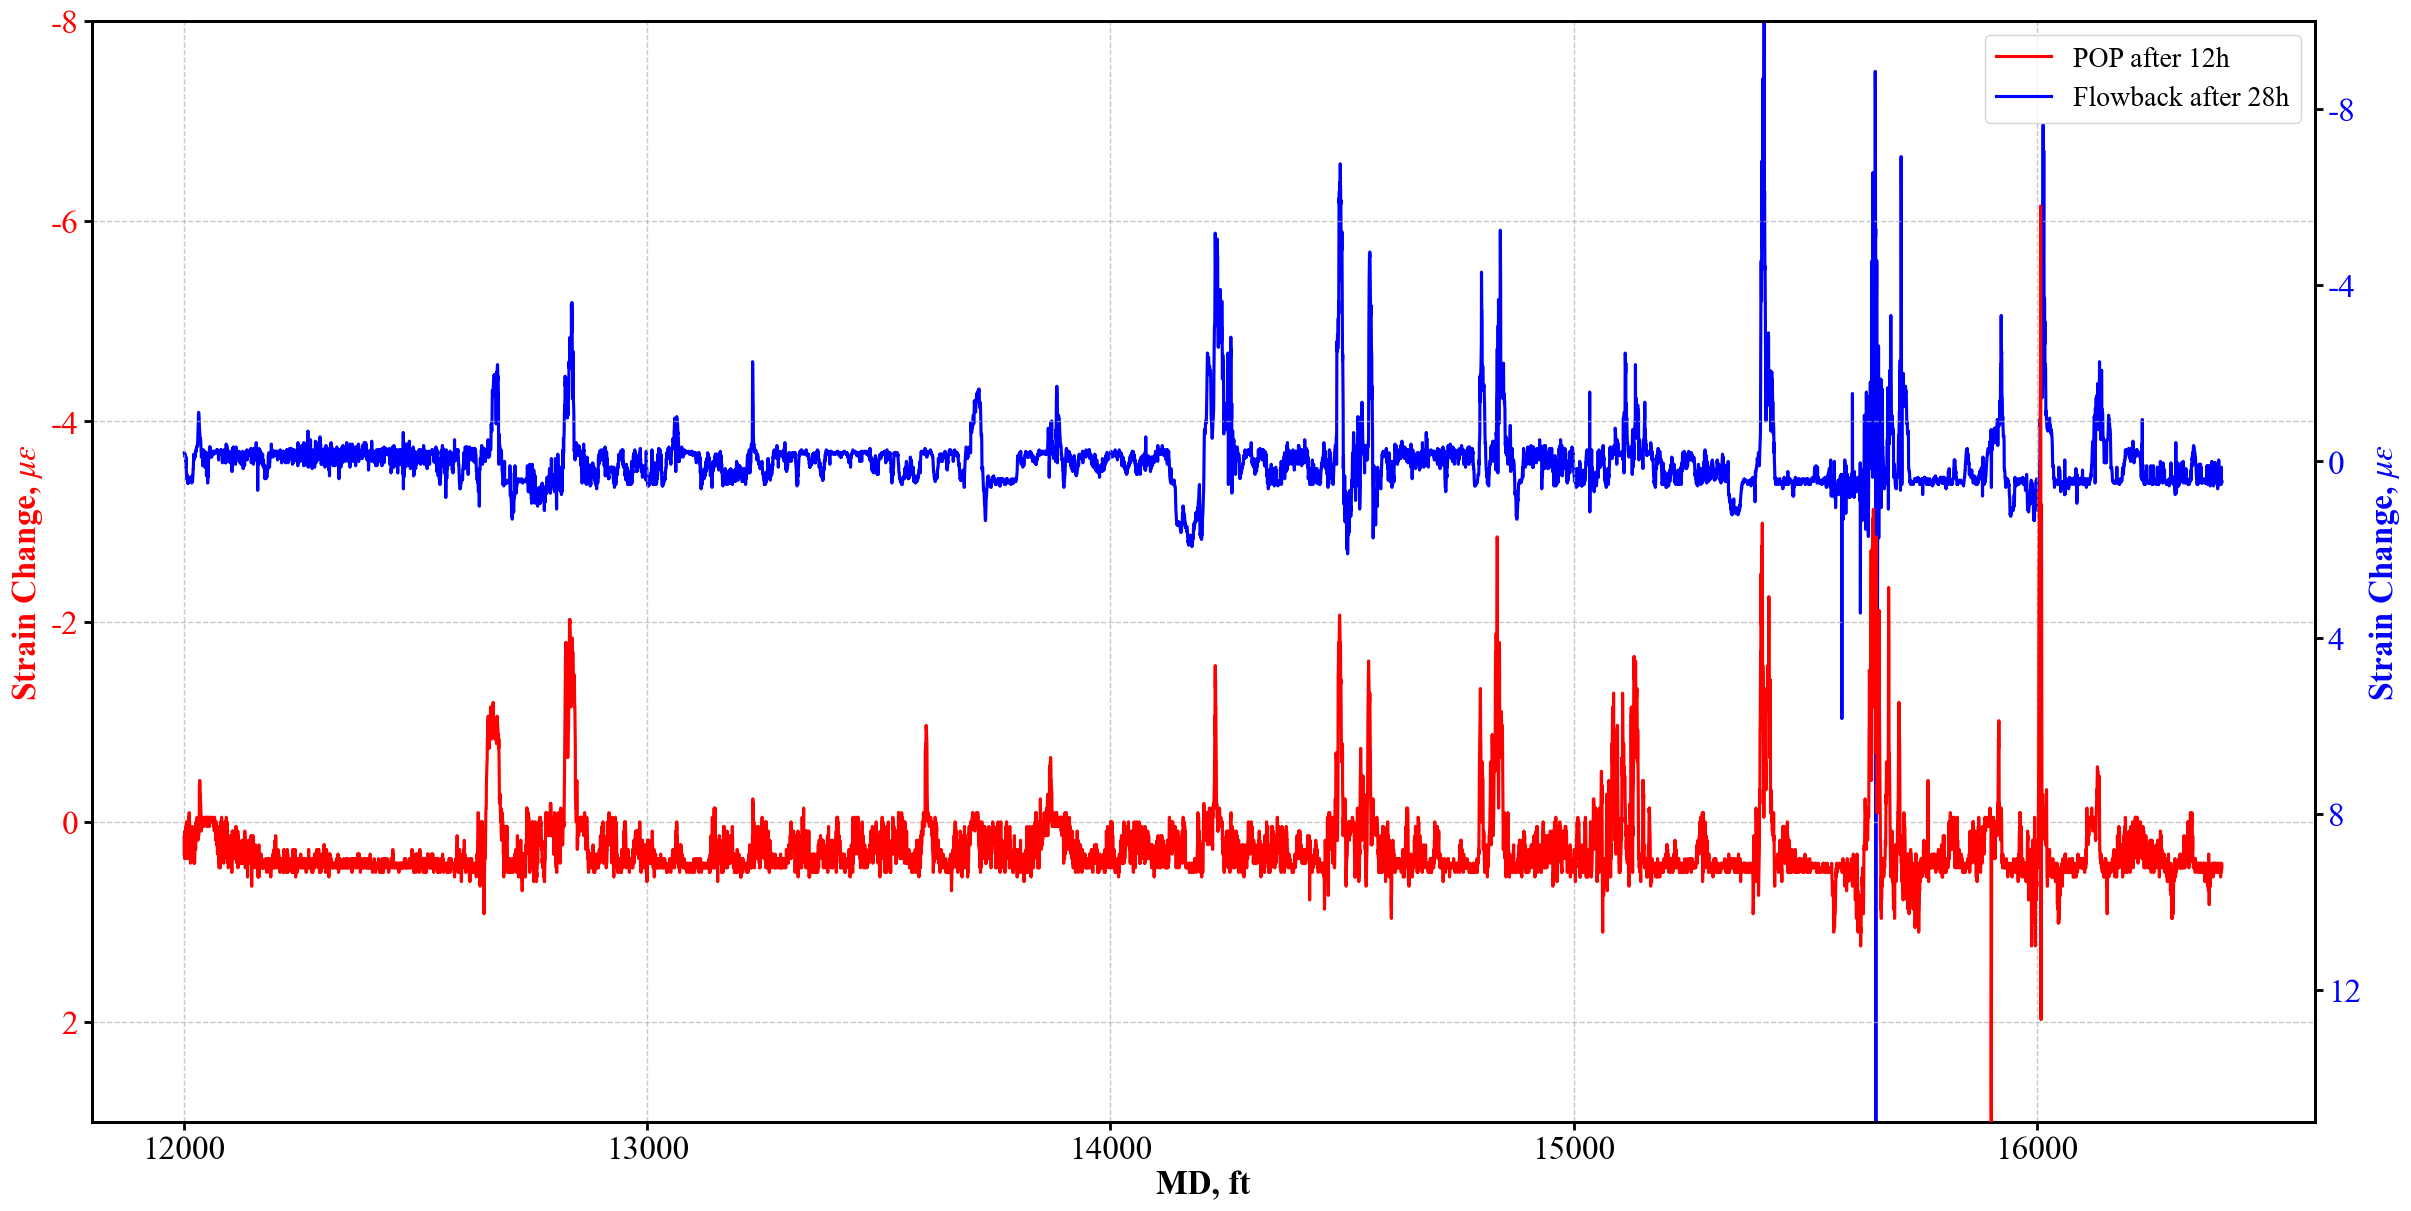

In [ ]:
%reload_ext autoreload
%autoreload 2

# =========================================================
# 左图（POP）也改成 interval profile：t_end - t_start
# =========================================================
left_path = r'C:/Users/fengxiang.mao/Desktop/Devon data/HFTS-1_Devon/20220707/Evo 5 (POP)/Zgabay A14H - pop - strain change.h5'

t_start_left = "2022-03-15 09:00:00"
t_end_left   = "2022-03-15 21:00:00"

interval_prof_left, depth1, dstrain1_fake, stamps1_fake, time_left_fake, dbg_left = build_interval_profile_from_file(
    h5_path=left_path,
    data_key="data",
    t_start=t_start_left,
    t_end=t_end_left,
    stamp_fmt='%m/%d/%Y %H:%M:%S.%f',
    sign=1.0
)

print("LEFT interval matched:", dbg_left)

times_left  = [time_left_fake]
window_left = (12000.0, 16400.0)


# -------------------------
# 右轴改成 interval profile：t_end - t_start
# -------------------------
flowback_path = 'C:/Users/fengxiang.mao/Desktop/Devon data/HFTS-1_Devon/Evo_5_6_7_Sep_2025/Evo 6 (choke)/corrected_within_1h_(with_data_wash).h5'


# 你自己填 interval 的两个时间点（示例）
t_start = "2022-04-03 01:00:00"
t_end   = "2022-04-04 01:00:00"

# sign=1 或 -1 看你想让 interval 的方向和你 output1 一致
interval_prof, depth2, dstrain2_fake, stamps2_fake, time_right_fake, dbg = build_interval_profile_from_file(
    h5_path=flowback_path,
    data_key="strain_corrected",
    t_start=t_start,
    t_end=t_end,
    stamp_fmt='%m/%d/%Y %H:%M:%S.%f',
    sign=1.0
)

print("Right interval matched:", dbg)
times_right = [time_right_fake]  # 注意：这是“伪造的唯一时间点”
# stamps_index_right 用 stamps2_fake
# dstrain_right 用 dstrain2_fake


# === 深度做分段 shift（保持你原来的 calibration 逻辑）===
depth2_shifted = shift_depth_piecewise(depth2, z0=12000.0, z1=16000.0, s0=-40, s1=-45)

window_right = (12000.0, 16400.0)

# -------------------------
# 画图：基本不改 plot_dual_axis_depth_profile 的接口
# -------------------------

fig, ax_left, ax_right = plot_dual_axis_depth_profile(
    dstrain_left=dstrain1_fake,
    depth_left=depth1,
    times_left=times_left,

    dstrain_right=dstrain2_fake,
    depth_right=depth2_shifted,
    times_right=times_right,

    depth_window_left=window_left,
    depth_window_right=window_right,

    stamps_index_left=stamps1_fake,
    stamps_index_right=stamps2_fake,

    depth_unit="ft",
    strain_unit_left=r"$\mu\varepsilon$",
    strain_unit_right=r"$\mu\varepsilon$",

    invert_left_y=False,
    invert_right_y=False,
    xlim=(12000.0, 16400.0),
    figsize=(24, 12),

    # 这里建议标签也改成 interval 含义
    labels=("POP after 12h", "Flowback after 28h"),
)


ax_left.set_xlim(12000-200, 16400+200)

ax_left.set_xticks(np.arange(12000, 16401, 1000))

ax_left.set_ylim(3, -8)
ax_left.yaxis.set_major_locator(MultipleLocator(2))

ax_right.set_ylim(15, -10)
ax_right.yaxis.set_major_locator(MultipleLocator(4))
# ax_right.lines[0].set_linestyle("-")



# 假设左轴第一条线是 refrac，右轴第一条线是 POP interval
ax_left.lines[0].set_zorder(10)   # 画到上面
ax_right.lines[0].set_zorder(5)   # 放下面（可选）

# 如果你发现“还是被盖住”，加上这句让上面的线不被轴背景挡住
ax_left.set_zorder(2)
ax_right.set_zorder(1)
ax_left.patch.set_alpha(0)        # 左轴背景透明，避免遮挡右轴线

ax_left.grid(True, linestyle='--',alpha=0.7)



In [24]:
print("left lines:", len(ax_left.lines))
print("right lines:", len(ax_right.lines))

left lines: 1
right lines: 1


LEFT interval matched: (514, Timestamp('2022-03-15 09:00:21.241823'), 1024, Timestamp('2022-03-15 21:00:08.100242'))
right interval matched: (458, Timestamp('2022-04-03 00:59:32.245172'), 903, Timestamp('2022-04-04 00:59:01.205751'))


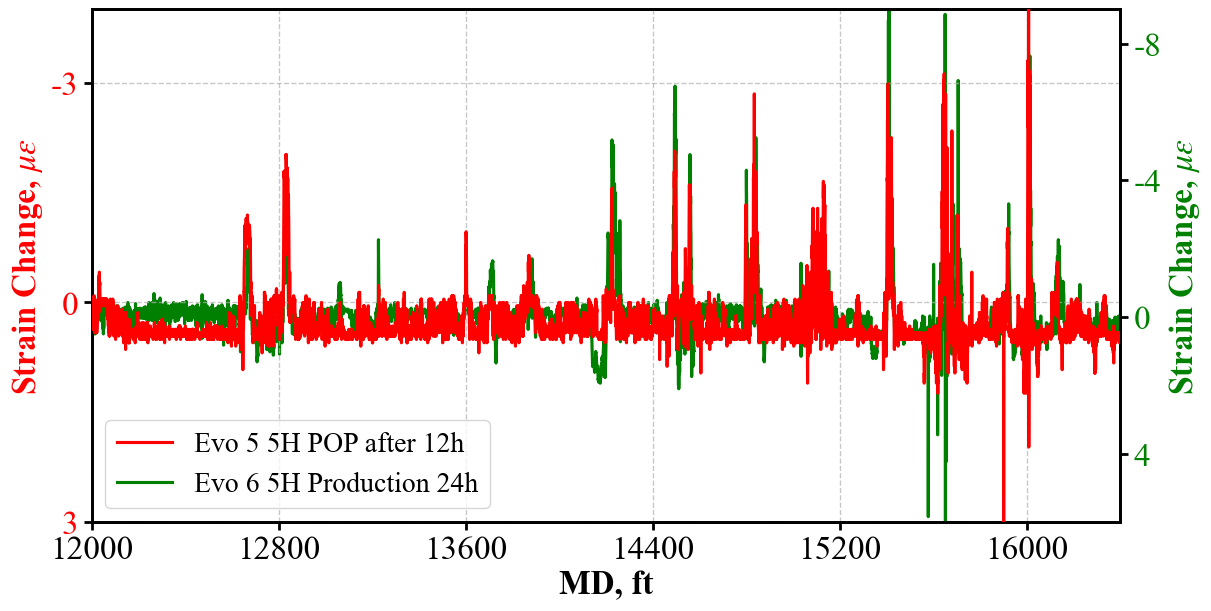

In [17]:
%reload_ext autoreload
%autoreload 2

# =========================================================
# 左图（POP）也改成 interval profile：t_end - t_start
# =========================================================
left_path = r'C:/Users/fengxiang.mao/Desktop/Devon data/HFTS-1_Devon/20220707/Evo 5 (POP)/Zgabay A14H - pop - strain change.h5'

t_start_left = "2022-03-15 09:00:00"
t_end_left   = "2022-03-15 21:00:00"

interval_prof_left, depth1, dstrain1_fake, stamps1_fake, time_left_fake, dbg_left = build_interval_profile_from_file(
    h5_path=left_path,
    data_key="data",
    t_start=t_start_left,
    t_end=t_end_left,
    stamp_fmt='%m/%d/%Y %H:%M:%S.%f',
    sign=1.0
)

print("LEFT interval matched:", dbg_left)

times_left  = [time_left_fake]
window_left = (12000.0, 16400.0)


# -------------------------
# 右轴改成 interval profile：t_end - t_start
# -------------------------
pop_path = 'C:/Users/fengxiang.mao/Desktop/Devon data/HFTS-1_Devon/Evo_5_6_7_Sep_2025/Evo 6 (choke)/corrected_within_1h_(with_data_wash).h5'


# 你自己填 interval 的两个时间点（示例）
t_start = "2022-04-03 01:00:00"
t_end   = "2022-04-04 01:00:00"

# sign=1 或 -1 看你想让 interval 的方向和你 output1 一致
interval_prof, depth2, dstrain2_fake, stamps2_fake, time_right_fake, dbg = build_interval_profile_from_file(
    h5_path=pop_path,
    data_key="strain_corrected",
    t_start=t_start,
    t_end=t_end,
    stamp_fmt='%m/%d/%Y %H:%M:%S.%f',
    sign=1.0
)

print("right interval matched:", dbg)
times_right = [time_right_fake]  # 注意：这是“伪造的唯一时间点”
# stamps_index_right 用 stamps2_fake
# dstrain_right 用 dstrain2_fake


# === 深度做分段 shift（保持你原来的 calibration 逻辑）===
depth2_shifted = shift_depth_piecewise(depth2, z0=12000.0, z1=16000.0, s0=-40, s1=-45)

window_right = (12000.0, 16400.0)

# -------------------------
# 画图：基本不改 plot_dual_axis_depth_profile 的接口
# -------------------------

fig, ax_left, ax_right = plot_dual_axis_depth_profile(
    dstrain_left=dstrain1_fake,
    depth_left=depth1,
    times_left=times_left,

    dstrain_right=dstrain2_fake,
    depth_right=depth2_shifted,
    times_right=times_right,

    depth_window_left=window_left,
    depth_window_right=window_right,

    stamps_index_left=stamps1_fake,
    stamps_index_right=stamps2_fake,

    depth_unit="ft",
    strain_unit_left=r"$\mu\varepsilon$",
    strain_unit_right=r"$\mu\varepsilon$",

    invert_left_y=False,
    invert_right_y=False,
    xlim=(12000.0, 16400.0),
    figsize=(12, 6),

    # 这里建议标签也改成 interval 含义
    labels=("Evo 5 5H POP after 12h", f"Evo 6 5H Production 24h"),
    left_color='r',
    right_color="g",
)


ax_left.set_ylim(3, -4)
# ax_left.set_yticks(np.arange(-3, 3, 3))
ax_left.yaxis.set_major_locator(MultipleLocator(3))

ax_right.set_ylim(6, -9)
ax_right.yaxis.set_major_locator(MultipleLocator(4))
# ax_right.lines[0].set_linestyle("-")



# 假设左轴第一条线是 refrac，右轴第一条线是 POP interval
ax_left.lines[0].set_zorder(5)   # 画到上面
ax_right.lines[0].set_zorder(10)   # 放下面（可选）

# 如果你发现“还是被盖住”，加上这句让上面的线不被轴背景挡住
ax_left.set_zorder(2)
ax_right.set_zorder(1)
ax_left.patch.set_alpha(0)        # 左轴背景透明，避免遮挡右轴线

ax_left.grid(True, linestyle='--',alpha=0.7)

leg = ax_left.legend_
if leg is not None:
    leg.set_zorder(1000)
    leg.get_frame().set_alpha(0.8)

# EVO 6 & 7 

In [33]:
import h5py
import numpy as np
import pandas as pd
from plot_style import decode_stamps_to_datetimeindex, plot_dual_axis_depth_profile
from slippage_clbrt_shift import shift_depth_piecewise
from matplotlib.ticker import MultipleLocator

def find_nearest_time_index(idx: pd.DatetimeIndex, target: pd.Timestamp) -> int:
    deltas = idx - target
    return int(np.abs(deltas).argmin())

def build_interval_profile_from_file(
    h5_path: str,
    data_key: str,
    t_start: str,   # e.g. "2022-03-16 20:10:00"
    t_end: str,     # e.g. "2022-03-16 20:50:03"
    stamp_fmt: str = '%m/%d/%Y %H:%M:%S.%f',
    sign: float = 1.0
):
    """
    返回：
      interval_profile_full: shape (ndepth,)  = sign * (profile_end - profile_start)
      depth:                shape (ndepth,)
      fake_dstrain_2d:       shape (1, ndepth)  (为了兼容原 plot 函数)
      fake_stamps_idx:       DatetimeIndex([matched_end_time])
      fake_time_str:         用于 times_right 的字符串
      debug:                 (i_start, matched_start, i_end, matched_end)
    """
    f = h5py.File(h5_path, "r")
    dstrain = f[data_key][...]          # (ntime, ndepth)
    depth   = np.asarray(f["depth"][...])
    stamps  = f["stamps"]
    stamps_idx = decode_stamps_to_datetimeindex(stamps, fmt=stamp_fmt)

    t_start_ts = pd.to_datetime(t_start)
    t_end_ts   = pd.to_datetime(t_end)

    i0 = find_nearest_time_index(stamps_idx, t_start_ts)
    i1 = find_nearest_time_index(stamps_idx, t_end_ts)

    prof0 = dstrain[i0, :]
    prof1 = dstrain[i1, :]
    interval_profile_full = sign * (prof1 - prof0)

    # ★关键：包装成“只有 1 行”的 2D，伪装成一个“时间点”
    fake_dstrain_2d = interval_profile_full[None, :]  # (1, ndepth)
    fake_stamps_idx = pd.DatetimeIndex([stamps_idx[i1]])
    fake_time_str   = str(fake_stamps_idx[0])

    debug = (i0, stamps_idx[i0], i1, stamps_idx[i1])
    return interval_profile_full, depth, fake_dstrain_2d, fake_stamps_idx, fake_time_str, debug


LEFT interval matched: (458, Timestamp('2022-04-03 00:59:32.245172'), 903, Timestamp('2022-04-04 00:59:01.205751'))
right interval matched: (566, Timestamp('2022-06-02 08:00:07.017492'), 1218, Timestamp('2022-06-03 11:59:53.654046'))


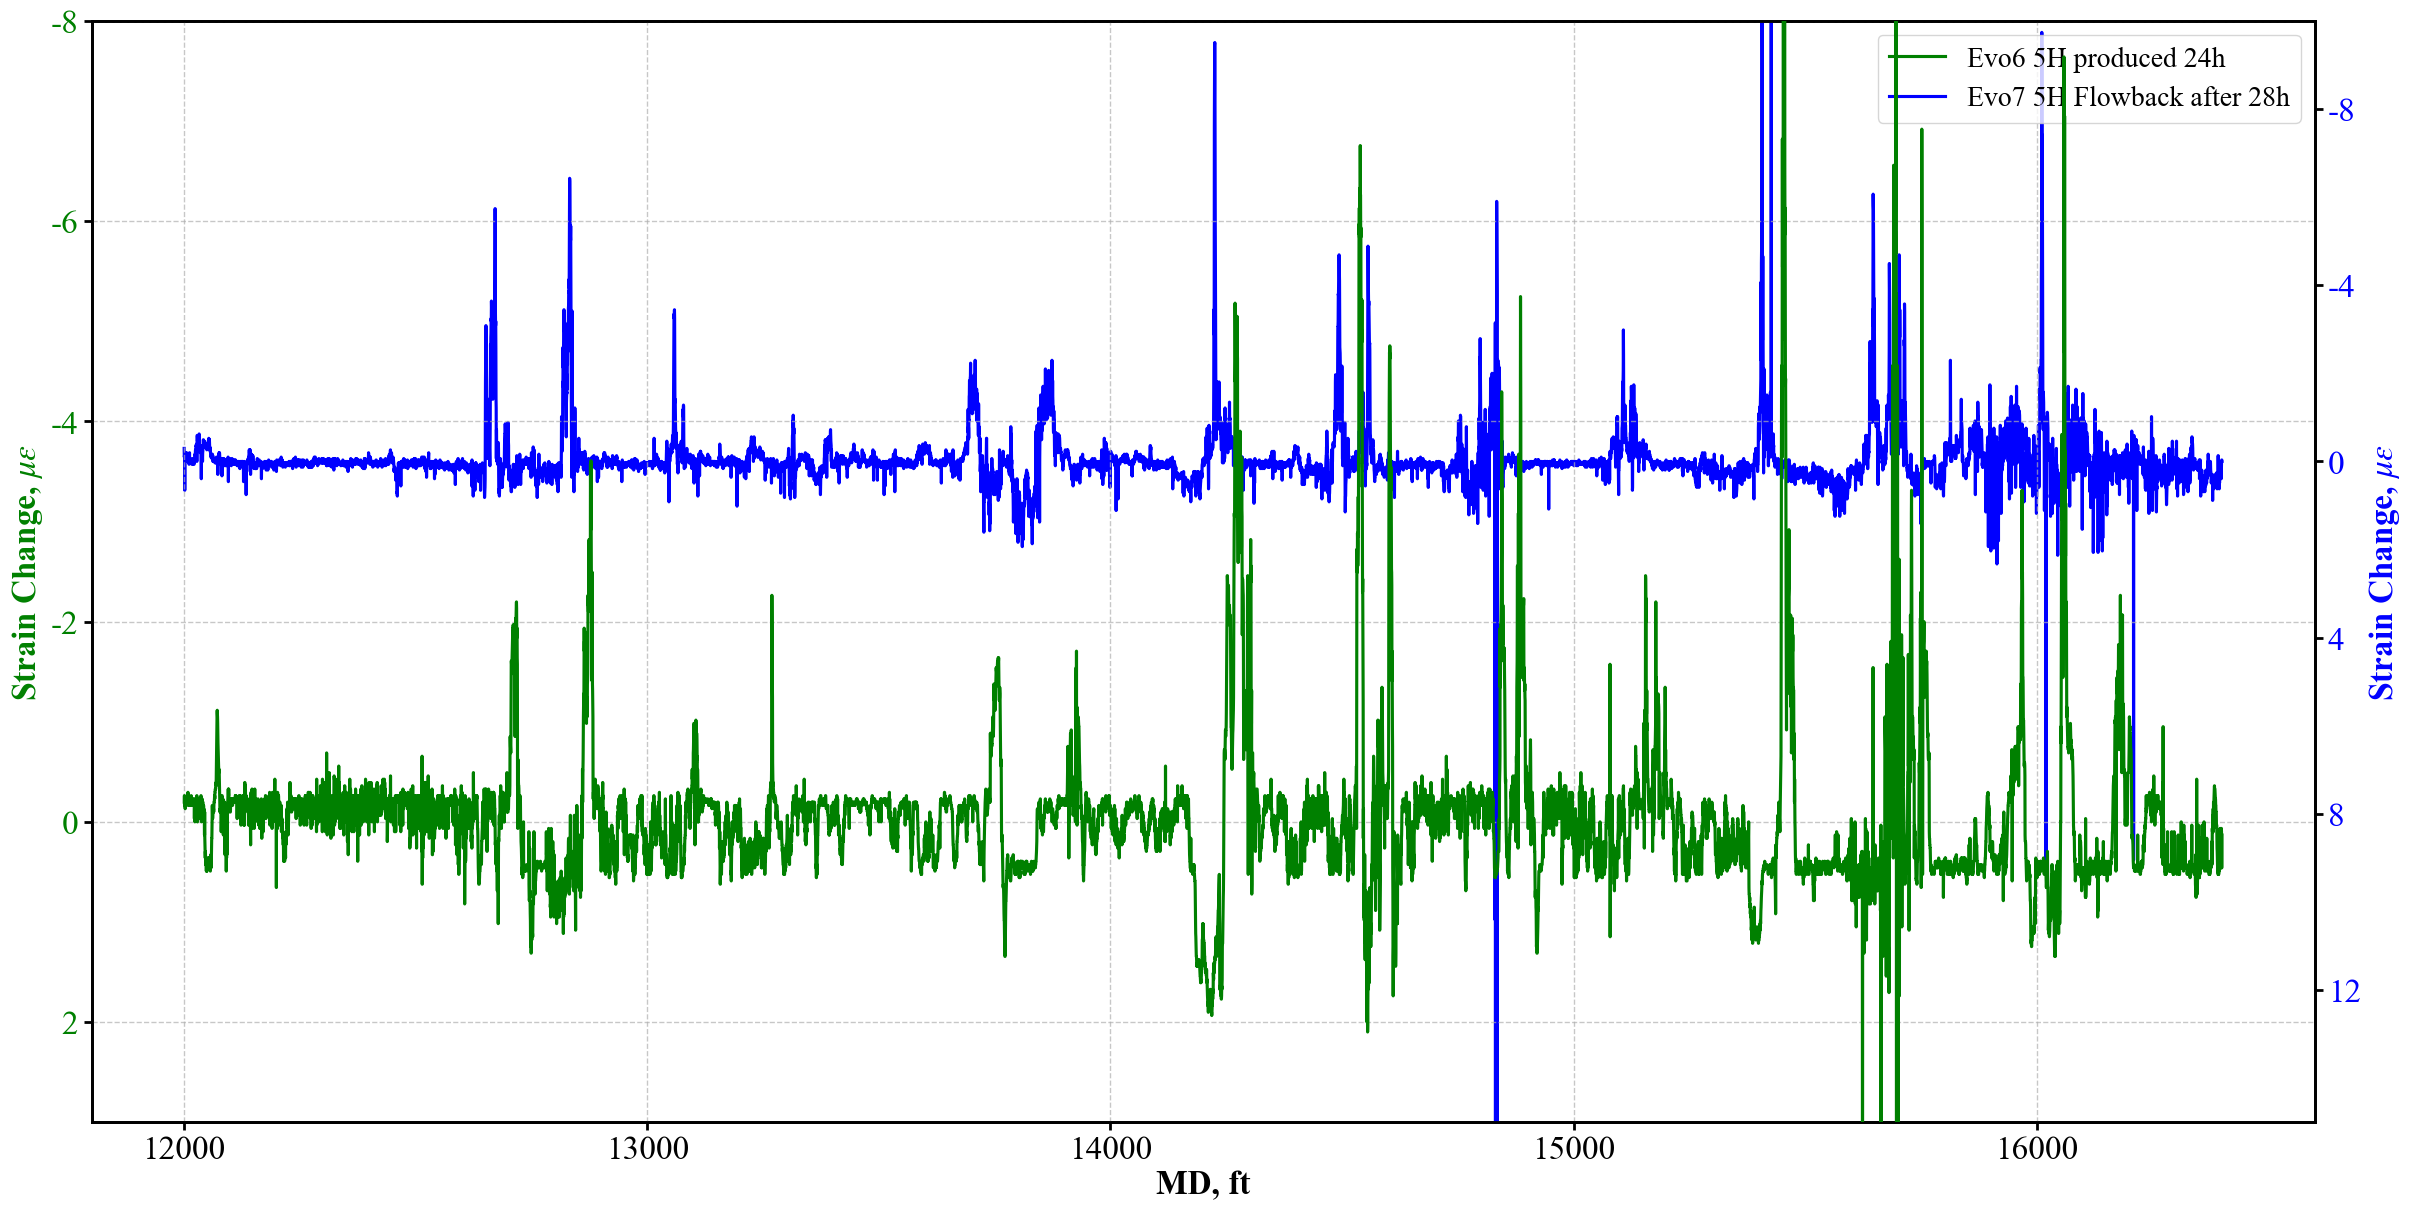

In [35]:
%reload_ext autoreload
%autoreload 2

# =========================================================
# 左图（POP）也改成 interval profile：t_end - t_start
# =========================================================

left_path = 'C:/Users/fengxiang.mao/Desktop/Devon data/HFTS-1_Devon/Evo_5_6_7_Sep_2025/Evo 6 (choke)/corrected_within_1h_(with_data_wash).h5'


# 你自己填 interval 的两个时间点（示例）
t_start_left = "2022-04-03 01:00:00"
t_end_left   = "2022-04-04 01:00:00"

# sign=1 或 -1 看你想让 interval 的方向和你 output1 一致
interval_prof_left, depth1, dstrain1_fake, stamps1_fake, time_left_fake, dbg_left = build_interval_profile_from_file(
    h5_path=left_path,
    data_key="strain_corrected",
    t_start=t_start_left,
    t_end=t_end_left,
    stamp_fmt='%m/%d/%Y %H:%M:%S.%f',
    sign=1.0
)

print("LEFT interval matched:", dbg_left)
times_left  = [time_left_fake]  # 注意：这是“伪造的唯一时间点”
window_left = (12000.0, 16400.0)




# -------------------------
# 右轴（POP）改成 interval profile：t_end - t_start
# -------------------------
right_path = 'C:/Users/fengxiang.mao/Desktop/Devon data/HFTS-1_Devon/Evo_5_6_7_Sep_2025/Evo 7 (flowback)/corrected_within_1h_(with_data_wash).h5'


# 你自己填 interval 的两个时间点（示例）
t_start = "2022-06-02 08:00:00"
t_end   = "2022-06-03 12:00:00"

# sign=1 或 -1 看你想让 interval 的方向和你 output1 一致
interval_prof, depth2, dstrain2_fake, stamps2_fake, time_right_fake, dbg_right = build_interval_profile_from_file(
    h5_path=right_path,
    data_key="strain_corrected",
    t_start=t_start,
    t_end=t_end,
    stamp_fmt='%m/%d/%Y %H:%M:%S.%f',
    sign=1.0
)

print("right interval matched:", dbg_right)
times_right = [time_right_fake]  # 注意：这是“伪造的唯一时间点”
# stamps_index_right 用 stamps2_fake
# dstrain_right 用 dstrain2_fake


# === 深度做分段 shift（保持你原来的 calibration 逻辑）===
depth2_shifted = shift_depth_piecewise(depth2, z0=12000.0, z1=16000.0, s0=-40, s1=-45)

window_right = (12000.0, 16400.0)

# -------------------------
# 画图：基本不改 plot_dual_axis_depth_profile 的接口
# -------------------------

fig, ax_left, ax_right = plot_dual_axis_depth_profile(
    dstrain_left=dstrain1_fake,
    depth_left=depth1,
    times_left=times_left,

    dstrain_right=dstrain2_fake,
    depth_right=depth2_shifted,
    times_right=times_right,

    depth_window_left=window_left,
    depth_window_right=window_right,

    stamps_index_left=stamps1_fake,
    stamps_index_right=stamps2_fake,

    depth_unit="ft",
    strain_unit_left=r"$\mu\varepsilon$",
    strain_unit_right=r"$\mu\varepsilon$",

    invert_left_y=False,
    invert_right_y=False,
    xlim=(12000.0, 16400.0),
    figsize=(24, 12),

    # 这里建议标签也改成 interval 含义
    labels=("Evo6 5H produced 24h", "Evo7 5H Flowback after 28h"),
    left_color='g',
    right_color="b",
)


ax_left.set_xlim(12000-200, 16400+200)

ax_left.set_xticks(np.arange(12000, 16401, 1000))

ax_left.set_ylim(3, -8)
ax_left.yaxis.set_major_locator(MultipleLocator(2))

ax_right.set_ylim(15, -10)
ax_right.yaxis.set_major_locator(MultipleLocator(4))
# ax_right.lines[0].set_linestyle("-")



# 假设左轴第一条线是 refrac，右轴第一条线是 POP interval
ax_left.lines[0].set_zorder(10)   # 画到上面
ax_right.lines[0].set_zorder(5)   # 放下面（可选）

# 如果你发现“还是被盖住”，加上这句让上面的线不被轴背景挡住
ax_left.set_zorder(2)
ax_right.set_zorder(1)
ax_left.patch.set_alpha(0)        # 左轴背景透明，避免遮挡右轴线

ax_left.grid(True, linestyle='--',alpha=0.7)



In [ ]:
print("left lines:", len(ax_left.lines))
print("right lines:", len(ax_right.lines))

left lines: 1
right lines: 1


LEFT interval matched: (458, Timestamp('2022-04-03 00:59:32.245172'), 903, Timestamp('2022-04-04 00:59:01.205751'))
POP interval matched: (566, Timestamp('2022-06-02 08:00:07.017492'), 1218, Timestamp('2022-06-03 11:59:53.654046'))


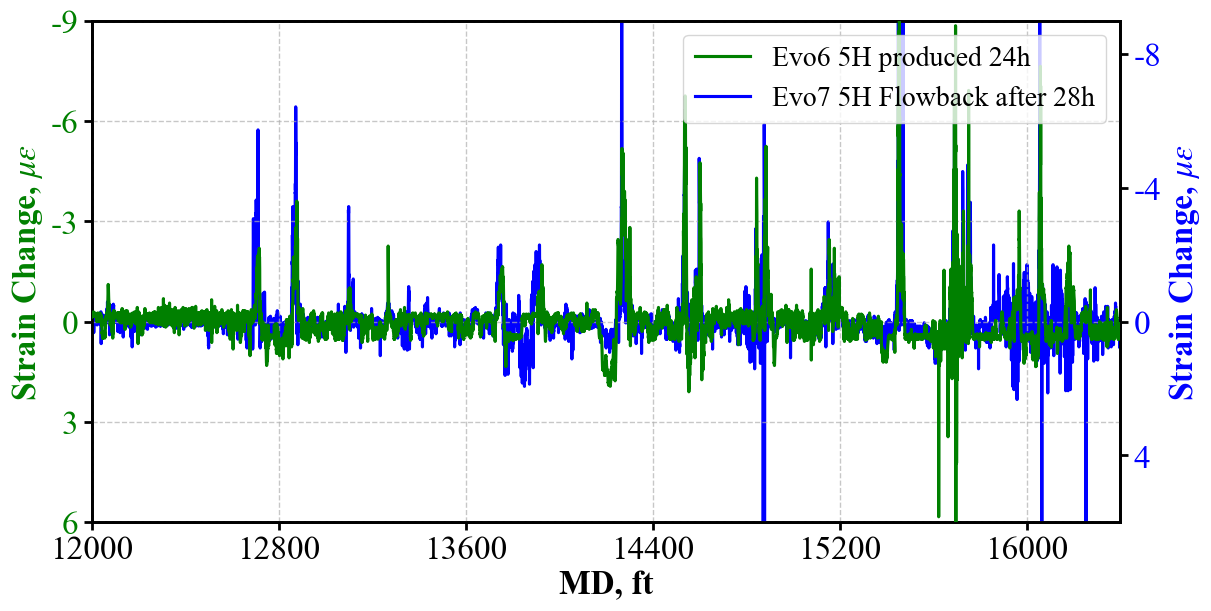

In [40]:
%reload_ext autoreload
%autoreload 2

# =========================================================
# 左图也改成 interval profile：t_end - t_start
# =========================================================


left_path = r'C:/Users/fengxiang.mao/Desktop/Devon data/HFTS-1_Devon/Evo_5_6_7_Sep_2025/Evo 6 (choke)/corrected_within_1h_(with_data_wash).h5'

t_start_left = "2022-04-03 01:00:00"
t_end_left   = "2022-04-04 01:00:00"

interval_prof_left, depth1, dstrain1_fake, stamps1_fake, time_left_fake, dbg_left = build_interval_profile_from_file(
    h5_path=left_path,
    data_key="strain_corrected",
    t_start=t_start_left,
    t_end=t_end_left,
    stamp_fmt='%m/%d/%Y %H:%M:%S.%f',
    sign=1.0
)

print("LEFT interval matched:", dbg_left)

times_left  = [time_left_fake]
window_left = (12000.0, 16400.0)


# -------------------------
# 右轴（POP）改成 interval profile：t_end - t_start
# -------------------------
pop_path = 'C:/Users/fengxiang.mao/Desktop/Devon data/HFTS-1_Devon/Evo_5_6_7_Sep_2025/Evo 7 (flowback)/corrected_within_1h_(with_data_wash).h5'


# 你自己填 interval 的两个时间点（示例）
t_start = "2022-06-02 08:00:00"
t_end   = "2022-06-03 12:00:00"

# sign=1 或 -1 看你想让 interval 的方向和你 output1 一致
interval_prof, depth2, dstrain2_fake, stamps2_fake, time_right_fake, dbg = build_interval_profile_from_file(
    h5_path=pop_path,
    data_key="strain_corrected",
    t_start=t_start,
    t_end=t_end,
    stamp_fmt='%m/%d/%Y %H:%M:%S.%f',
    sign=1.0
)

print("POP interval matched:", dbg)
times_right = [time_right_fake]  # 注意：这是“伪造的唯一时间点”
# stamps_index_right 用 stamps2_fake
# dstrain_right 用 dstrain2_fake


# === 深度做分段 shift（保持你原来的 calibration 逻辑）===
depth2_shifted = shift_depth_piecewise(depth2, z0=12000.0, z1=16000.0, s0=0, s1=0)

window_right = (12000.0, 16400.0)

# -------------------------
# 画图：基本不改 plot_dual_axis_depth_profile 的接口
# -------------------------

fig, ax_left, ax_right = plot_dual_axis_depth_profile(
    dstrain_left=dstrain1_fake,
    depth_left=depth1,
    times_left=times_left,

    dstrain_right=dstrain2_fake,
    depth_right=depth2_shifted,
    times_right=times_right,

    depth_window_left=window_left,
    depth_window_right=window_right,

    stamps_index_left=stamps1_fake,
    stamps_index_right=stamps2_fake,

    depth_unit="ft",
    strain_unit_left=r"$\mu\varepsilon$",
    strain_unit_right=r"$\mu\varepsilon$",

    invert_left_y=False,
    invert_right_y=False,
    xlim=(12000.0, 16400.0),
    figsize=(12, 6),

    # 这里建议标签也改成 interval 含义
    labels=("Evo6 5H produced 24h", "Evo7 5H Flowback after 28h"),
    left_color='g',
    right_color="b",
)


ax_left.set_ylim(6, -9)
ax_left.yaxis.set_major_locator(MultipleLocator(3))

ax_right.set_ylim(6, -9)
ax_right.yaxis.set_major_locator(MultipleLocator(4))
# ax_right.lines[0].set_linestyle("-")



# 假设左轴第一条线是 refrac，右轴第一条线是 POP interval
ax_left.lines[0].set_zorder(10)   # 画到上面
ax_right.lines[0].set_zorder(5)   # 放下面（可选）

# 如果你发现“还是被盖住”，加上这句让上面的线不被轴背景挡住
ax_left.set_zorder(2)
ax_right.set_zorder(1)
ax_left.patch.set_alpha(0)        # 左轴背景透明，避免遮挡右轴线

ax_left.grid(True, linestyle='--',alpha=0.7)

leg = ax_left.legend_
if leg is not None:
    leg.set_zorder(1000)
    leg.get_frame().set_alpha(0.8)